In [1]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [2]:
image_size=256
channels=3
image_shape = (image_size,image_size,channels)
batch_size=8
n_classes=3

In [3]:
dataset=tf.keras. preprocessing.image_dataset_from_directory(
    r"C:\Users\Sadiya Sajid\Downloads\potato_disease\PlantVillage",
    shuffle=True,
    image_size=(image_size,image_size),
    batch_size=batch_size
)

Found 2152 files belonging to 3 classes.


In [4]:
for images, labels in dataset.take(1):
    print(images.shape)


(8, 256, 256, 3)


In [5]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [6]:
len(dataset)

269

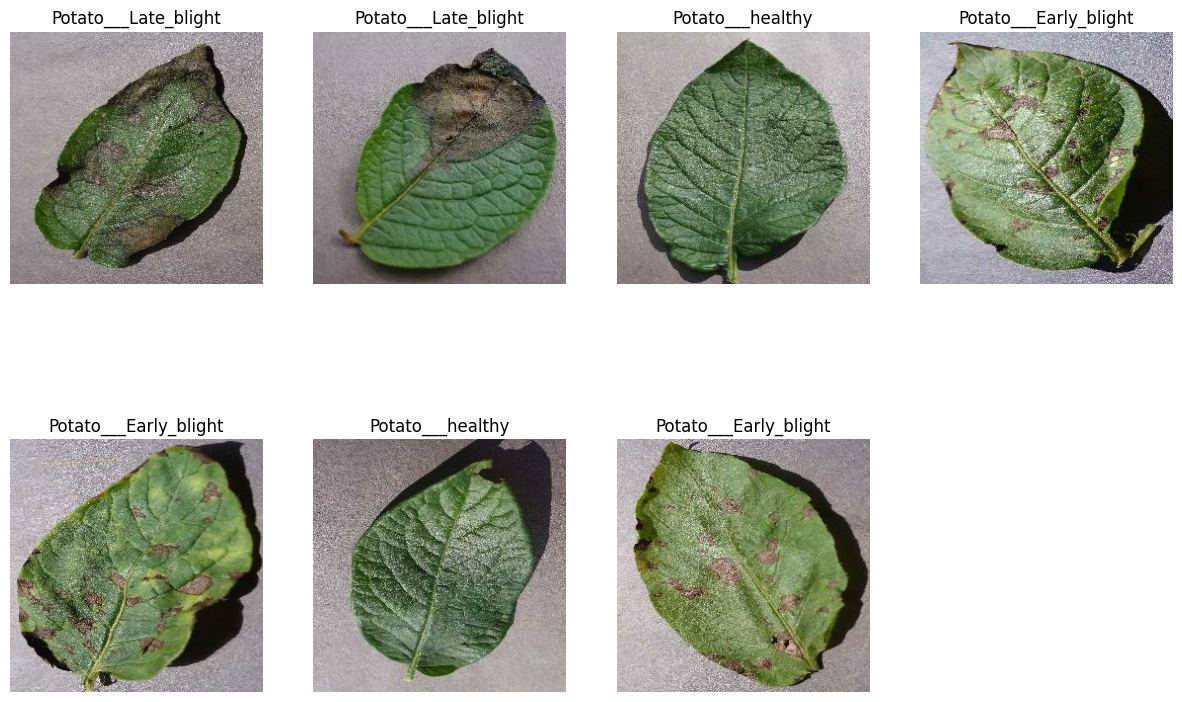

In [7]:
plt.figure(figsize=(15,15))
for image_batch,label_batch in dataset.take(1):
    for i in range(7):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [8]:
def dataset_partition(ds,train_split=0.7,val_split=0.15,test_split=0.15,shuffle=True,shuffle_size=1000):
    ds_size=len(ds)

    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=12)

    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)

    train_ds=ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)
    
    return train_ds,val_ds,test_ds

In [9]:
train_ds,val_ds,test_ds=dataset_partition(dataset)

In [10]:
len(train_ds)

188

In [11]:
len(val_ds)

40

In [12]:
len(test_ds)

41

In [13]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [14]:
resize_and_rescaling=tf.keras.Sequential([
    layers.Resizing(256,256),
    layers.Rescaling(1.0/255)
])

In [15]:
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [16]:
model = tf.keras.Sequential([
    resize_and_rescaling,
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

model.build((None, image_size, image_size, channels))



In [17]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 256, 256, 3)       0         
                                                                 
 sequential_1 (Sequential)   (None, 256, 256, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                 

In [18]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [19]:
history=model.fit(
    train_ds,
    epochs=25,
    batch_size=batch_size,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/25


188/188 [==============================] - 32s 140ms/step - loss: 0.6234 - accuracy: 0.7088 - val_loss: 0.4019 - val_accuracy: 0.8344
Epoch 2/25
188/188 [==============================] - 28s 150ms/step - loss: 0.3349 - accuracy: 0.8551 - val_loss: 0.3498 - val_accuracy: 0.8813
Epoch 3/25
188/188 [==============================] - 28s 150ms/step - loss: 0.2713 - accuracy: 0.9089 - val_loss: 0.2614 - val_accuracy: 0.9125
Epoch 4/25
188/188 [==============================] - 29s 154ms/step - loss: 0.2065 - accuracy: 0.9255 - val_loss: 0.1514 - val_accuracy: 0.9312
Epoch 5/25
188/188 [==============================] - 29s 152ms/step - loss: 0.2043 - accuracy: 0.9156 - val_loss: 0.4020 - val_accuracy: 0.8438
Epoch 6/25
188/188 [==============================] - 28s 150ms/step - loss: 0.1921 - accuracy: 0.9282 - val_loss: 0.1140 - val_accuracy: 0.9594
Epoch 7/25
188/188 [==============================] - 28s 151ms/step - loss: 0.1900 - accuracy: 0.9249 - val_loss: 0.1712 - val_

In [20]:
scores=model.evaluate(test_ds)

41/41 [==============================] - 3s 47ms/step - loss: 0.1530 - accuracy: 0.9451


In [21]:
history.params

{'verbose': 1, 'epochs': 25, 'steps': 188}

In [22]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [23]:
acc=history.history["accuracy"]
val_acc=history.history["val_accuracy"]

loss=history.history["loss"]
val_loss=history.history["val_loss"]

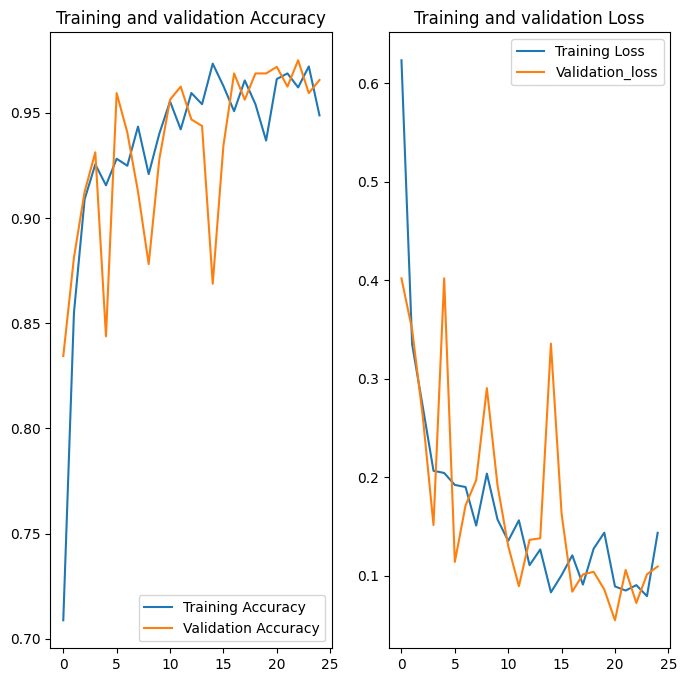

In [24]:
epochs=25
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(epochs),acc,label="Training Accuracy")
plt.plot(range(epochs),val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and validation Accuracy")

plt.subplot(1,2,2)
plt.plot(range(epochs),loss,label="Training Loss")
plt.plot(range(epochs),val_loss,label="Validation_loss")
plt.legend(loc="upper right")
plt.title("Training and validation Loss")

plt.show()

Actual Image:  Potato___Late_blight
1/1 [==============================] - 0s 151ms/step
Predicted Image Potato___Late_blight


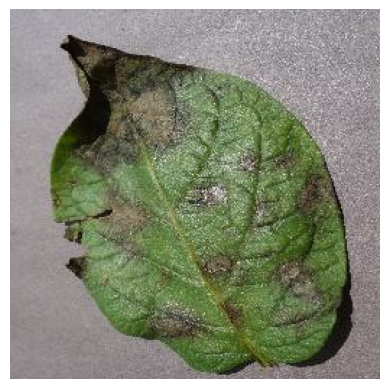

In [25]:
import numpy as np
for images_batch,labels_batch in test_ds.take(1):
    first_image=images_batch[0].numpy().astype("uint8")
    first_label=labels_batch[0].numpy()

    plt.imshow(first_image)
    print("Actual Image: ",class_names[first_label])
    predict=model.predict(images_batch)
    print("Predicted Image",class_names[np.argmax(predict[0])])
    plt.axis("off")
    

In [26]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)

    predictions=model.predict(img_array)

    predict_class=class_names[np.argmax(predictions[0])]
    confidence=round(100*(np.max(predictions[0])),2)

    return predict_class,confidence

1/1 [==============================] - 0s 29ms/step


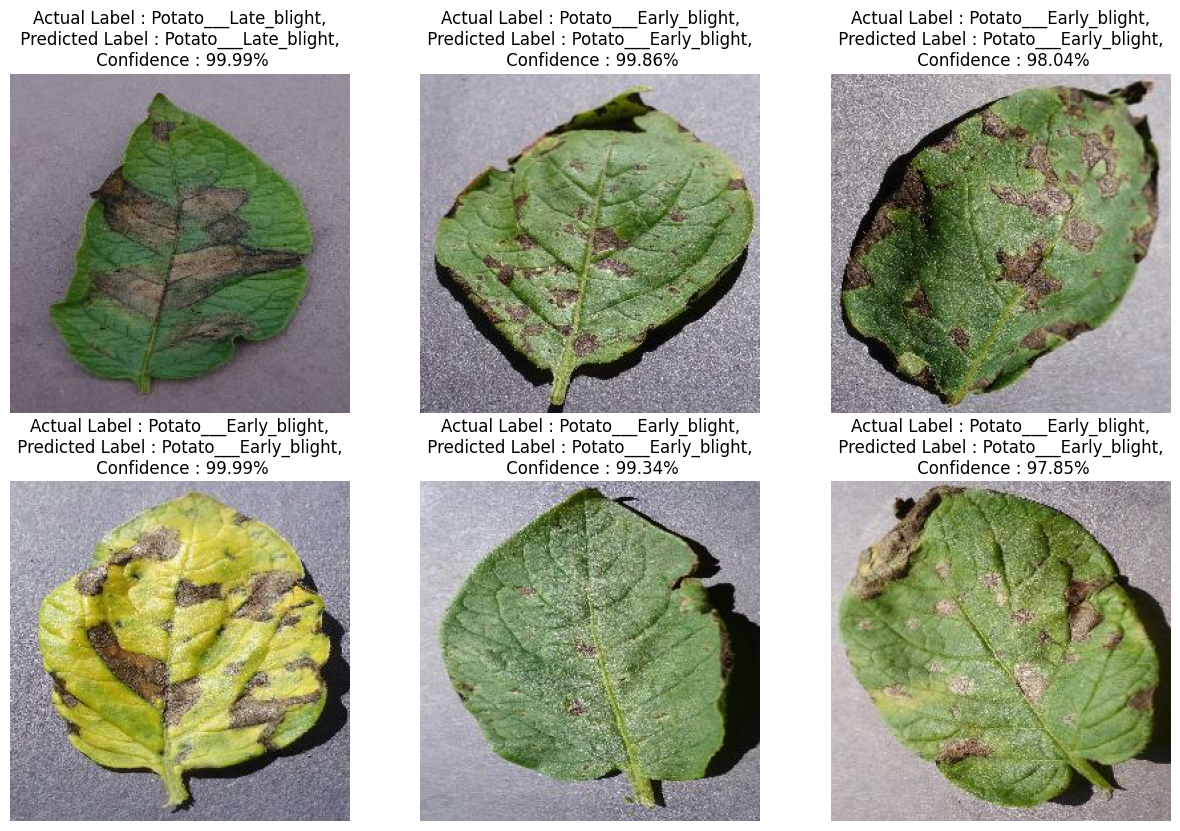

In [27]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for i in range(6):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predict_class,confidence=predict(model,images[i].numpy())
        actual_class=class_names[labels[i]]

        plt.title(f"Actual Label : {actual_class},\n Predicted Label : {predict_class}, \n Confidence : {confidence}%")
        plt.axis("off")
    

In [28]:
model_version=1
model.save(f"../model/{model_version}")

INFO:tensorflow:Assets written to: ../model/1\assets


INFO:tensorflow:Assets written to: ../model/1\assets


In [30]:
model.save("../model/leafguard_model.h5", save_format="h5")
